# Naive Bayes Classifier — Theory, Math, Implementation

This notebook covers:

- Bayes Theorem
- Naive Assumption
- Full mathematical derivation
- Manual probability calculation
- Zero-frequency problem
- Laplace smoothing
- Log probabilities
- Types of Naive Bayes
- Hyperparameter tuning
- Comparison with Logistic Regression
- Decision boundary visualization


## 1. Intuition

Naive Bayes answers:

> Given some observed features, what is the probability of each class?

Example:
- Given words in an email → is it spam?

Core idea:
- Use Bayes’ theorem
- Assume features are conditionally independent
- Choose class with highest posterior probability


## 2. Bayes' Theorem

$$
P(A \mid B) = \frac{P(B \mid A) P(A)}{P(B)}
$$

For classification:

$$
P(y \mid X) = \frac{P(X \mid y) P(y)}{P(X)}
$$

Where:

- $P(y)$ = Prior
- $P(X|y)$ = Likelihood
- $P(y|X)$ = Posterior
- $P(X)$ = Evidence

Since $P(X)$ is constant across classes:

$$
\hat{y} = \arg\max_y P(X \mid y) P(y)
$$


## 3. The Naive Assumption

True joint probability:

$$
P(x_1, x_2, ..., x_n \mid y)
$$

Naive assumption:

$$
P(x_1, ..., x_n \mid y)
=
\prod_{i=1}^{n} P(x_i \mid y)
$$

This makes the model computationally efficient.


## 4. Full Mathematical Derivation

### Step 1: Log Posterior

Starting from Bayes' theorem:

$$
P(y \mid x) = \frac{P(y)\prod_{i} P(x_i \mid y)}{P(x)}
$$

Taking the logarithm:

$$
\log P(y \mid x) = \log P(y) + \sum_i \log P(x_i \mid y) - \log P(x)
$$

Since $$\log P(x)$$ is constant for all classes, we focus on:

$$
\log P(y \mid x) = \log P(y) + \sum_i \log P(x_i \mid y)
$$

---

### Step 2: Log-Odds Ratio

Compute the log-odds between the two classes:

$$
\log \frac{P(y=1 \mid x)}{P(y=0 \mid x)}
$$

Substitute the log-posterior expression:

$$
\log \frac{P(y=1)}{P(y=0)}
+
\sum_i
\log \frac{P(x_i \mid y=1)}{P(x_i \mid y=0)}
$$

Rewriting:

$$
\log \frac{P(y=1 \mid x)}{P(y=0 \mid x)}
=
w_0 + \sum_i w_i x_i
$$

where:

- $$ w_0 = \log \frac{P(y=1)}{P(y=0)} $$
- $$ w_i = \log \frac{P(x_i \mid y=1)}{P(x_i \mid y=0)} $$

---

👉 **Linear decision boundary in log-space.**


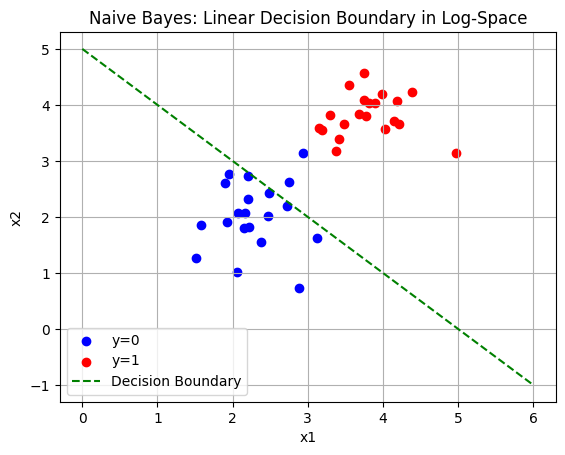

In [1]:
import numpy as np
import matplotlib.pyplot as plt

# Example 2D features (x1, x2) and labels y
np.random.seed(0)
x1_class0 = np.random.normal(2, 0.5, 20)
x2_class0 = np.random.normal(2, 0.5, 20)

x1_class1 = np.random.normal(4, 0.5, 20)
x2_class1 = np.random.normal(4, 0.5, 20)

# Stack features
X0 = np.column_stack([x1_class0, x2_class0])
X1 = np.column_stack([x1_class1, x2_class1])

# Plot points
plt.scatter(X0[:,0], X0[:,1], color='blue', label='y=0')
plt.scatter(X1[:,0], X1[:,1], color='red', label='y=1')

# Compute linear decision boundary (example coefficients from log-odds)
# log(P(y=1)/P(y=0)) + w1*x1 + w2*x2 = 0  => x2 = -(w0 + w1*x1)/w2
w0 = -5
w1 = 1
w2 = 1
x_vals = np.linspace(0, 6, 100)
y_vals = -(w0 + w1*x_vals)/w2

plt.plot(x_vals, y_vals, color='green', linestyle='--', label='Decision Boundary')

plt.xlabel('x1')
plt.ylabel('x2')
plt.title('Naive Bayes: Linear Decision Boundary in Log-Space')
plt.legend()
plt.grid(True)
plt.show()


## Small Table Manual Calculation (Spam Example)

### 1️⃣ Dataset

Word   | Spam Count | Not Spam Count
-------|------------|----------------
Buy    | 3          | 1
Free   | 2          | 0
Offer  | 1          | 2

Total messages: Spam = 4, Not Spam = 3

---

### 2️⃣ Compute Priors

$$
P(Spam) = 4/7 \approx 0.571
$$

$$
P(Not\ Spam) = 3/7 \approx 0.429
$$

---

### 3️⃣ Likelihoods (Original, no smoothing)

Total words in Spam = 6, Not Spam = 3  

- **Spam class:**  
  - P(Buy | Spam) = 3/6 = 0.5  
  - P(Free | Spam) = 2/6 ≈ 0.333  
  - P(Offer | Spam) = 1/6 ≈ 0.167  

- **Not Spam class:**  
  - P(Buy | Not Spam) = 1/3 ≈ 0.333  
  - **P(Free | Not Spam) = 0**  
  - P(Offer | Not Spam) = 2/3 ≈ 0.667  

Formula reference:  
$$
P(Word|Class) = \frac{Word\ Count\ in\ Class}{Total\ Words\ in\ Class}
$$

---

### 4️⃣ Zero-Frequency Issue and Laplace Smoothing

Vocabulary size V = 3  

- **Spam class (smoothed):**  
  - P(Buy | Spam) = (3+1)/(6+3) = 0.444  
  - P(Free | Spam) = (2+1)/9 = 0.333  
  - P(Offer | Spam) = (1+1)/9 ≈ 0.222  

- **Not Spam class (smoothed):**  
  - P(Buy | Not Spam) = (1+1)/(3+3) = 0.333  
  - **P(Free | Not Spam) = (0+1)/6 ≈ 0.167**  
  - P(Offer | Not Spam) = (2+1)/6 = 0.5  

Formula:  
$$
P(Word|Class) = \frac{Word\ Count + 1}{Total\ Words + V}
$$

---

### 5️⃣ Manually Classify Example

Message: `"Buy Free"`

Posterior for Spam:

$$
P(Spam|Buy, Free) \propto 0.571 * 0.444 * 0.333 \approx 0.084
$$

Posterior for Not Spam:

$$
P(Not\ Spam|Buy, Free) \propto 0.429 * 0.333 * 0.167 \approx 0.024
$$

✅ Since 0.084 > 0.024 → classify as **Spam**.

---

### ✅ Takeaways

1. Priors = probability of each class  
2. Likelihoods = probability of word given class  
3. Posterior = product of prior and likelihoods  
4. Zero-frequency → use Laplace smoothing  
5. Manual computation shows Naive Bayes **without sklearn**


## Why Use Log Probabilities?

In Naive Bayes, the posterior is computed as:

$$
P(Class | x) \propto P(Class) \prod_i P(x_i | Class)
$$

When multiplying many small probabilities, the product can become **extremely small** → **underflow**.  

To avoid this, we use **log probabilities**:

$$
\log P(Class | x) \propto \log P(Class) + \sum_i \log P(x_i | Class)
$$

- Multiplying small numbers → very tiny values → underflow  
- Summing logs → numerically stable, avoids underflow


In [2]:
import numpy as np

# Small probabilities
probs = [0.01, 0.001, 0.0001, 0.00001]

# Naive product (can underflow)
prod = np.prod(probs)
print("Product:", prod)

# Using log probabilities
log_sum = np.sum(np.log(probs))
print("Log-sum:", log_sum)

# Convert back to probability
prob_from_log = np.exp(log_sum)
print("Recovered probability from log:", prob_from_log)


Product: 1.0000000000000002e-14
Log-sum: -32.23619130191664
Recovered probability from log: 9.999999999999987e-15


## Types of Naive Bayes – Detailed Explanation

---

### 1️⃣ Gaussian Naive Bayes (Gaussian NB)

**Overview:**  
Gaussian NB is designed for **continuous numerical features**. It assumes that each feature within a class follows a **normal (Gaussian) distribution** – a bell-shaped curve where values cluster around a mean and spread according to a standard deviation.  

**Assumptions:**  
- Features are continuous and independent given the class.  
- Each feature has its own mean (μ) and variance (σ²) per class.  
- If all classes share the same variance, the **decision boundary is linear**.  

**Applications:**  
- Predicting physical measurements like height, weight, or temperature.  
- Classifying medical readings (blood pressure, glucose levels).  
- Detecting anomalies in sensor networks (e.g., identifying unusual sensor values).  

**Decision Rule:**  

$$
P(x_i | y) = \frac{1}{\sqrt{2 \pi \sigma_y^2}} \exp\Big(- \frac{(x_i - \mu_y)^2}{2 \sigma_y^2}\Big)
$$

Where:  
- \(x_i\) = feature value  
- μ_y = mean of the feature for class y  
- σ²_y = variance of the feature for class y  


### 2️⃣ Multinomial Naive Bayes (Multinomial NB)

**Overview:**  
- Designed for **discrete count data**, e.g., word counts in documents.  
- Models the probability of observing a given feature count in each class.  
- Features are independent given the class.  
- Often uses **Laplace smoothing** to handle unseen features.

**Applications:**  
- Spam detection or sentiment analysis based on word counts.  
- Document categorization.  
- Recommendation systems using count/frequency data.

**Decision Rule (smoothed):**

$$
P(x_i | y) = \frac{\text{count of feature i in class y} + 1}{\text{total count in class y} + V}
$$

Where:  
- \(V\) = number of possible features (vocabulary size).  


### 3️⃣ Bernoulli Naive Bayes (Bernoulli NB)

**Overview:**  
- Designed for **binary features** (presence or absence of a feature).  
- Each feature is either 0 (absent) or 1 (present).  
- Features are assumed **independent given the class**.  
- Laplace smoothing is often used to avoid zero probabilities.

**Applications:**  
- Spam detection based on whether certain keywords are present.  
- Document classification where **presence/absence** of words matters more than frequency.  
- Binary feature-based anomaly detection in datasets.

**Decision Rule:**  

$$
P(x_i | y) = p_i^{x_i} (1 - p_i)^{1 - x_i}
$$

Where:  
- \(p_i\) = probability that feature i is present in class y  
- \(x_i = 1\) if the feature is present, 0 if absent  


## Naive Bayes Implementation on a Real Dataset

We will demonstrate **GaussianNB, MultinomialNB, and BernoulliNB** using a simple dataset.

---

### Load Dataset

We’ll use the **breast cancer dataset** from sklearn for continuous features. For MultinomialNB and BernoulliNB, we will discretize or binarize the features.



In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import KBinsDiscretizer, Binarizer
from sklearn.metrics import accuracy_score, confusion_matrix, precision_score, recall_score

# Load dataset
data = load_breast_cancer()
X, y = data.data, data.target

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


In [4]:
from sklearn.naive_bayes import GaussianNB

gnb = GaussianNB()
gnb.fit(X_train, y_train)
y_pred = gnb.predict(X_test)

print("GaussianNB Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))


GaussianNB Accuracy: 0.9736842105263158
Confusion Matrix:
 [[40  3]
 [ 0 71]]
Precision: 0.9594594594594594
Recall: 1.0


In [5]:
from sklearn.naive_bayes import MultinomialNB
import numpy as np

# Discretize features into 10 bins
kb = KBinsDiscretizer(n_bins=10, encode='ordinal', strategy='uniform')
X_train_disc = kb.fit_transform(X_train)
X_test_disc = kb.transform(X_test)

mnb = MultinomialNB()
mnb.fit(X_train_disc, y_train)
y_pred = mnb.predict(X_test_disc)

print("MultinomialNB Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))


MultinomialNB Accuracy: 0.8947368421052632
Confusion Matrix:
 [[38  5]
 [ 7 64]]
Precision: 0.927536231884058
Recall: 0.9014084507042254


In [6]:
from sklearn.naive_bayes import BernoulliNB
from sklearn.preprocessing import Binarizer

binarizer = Binarizer()
X_train_bin = binarizer.fit_transform(X_train)
X_test_bin = binarizer.transform(X_test)

bnb = BernoulliNB()
bnb.fit(X_train_bin, y_train)
y_pred = bnb.predict(X_test_bin)

print("BernoulliNB Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))


BernoulliNB Accuracy: 0.6228070175438597
Confusion Matrix:
 [[ 0 43]
 [ 0 71]]
Precision: 0.6228070175438597
Recall: 1.0


| Model          | Accuracy | Precision | Recall | Notes                                                                                                             |
| -------------- | -------- | --------- | ------ | ----------------------------------------------------------------------------------------------------------------- |
| **GaussianNB** | 0.974    | 0.959     | 1.0    | Works best for continuous features; decision boundary fits the data well.                                         |
| MultinomialNB  | 0.927    | 0.928     | 0.901  | Decent, but discretizing continuous features loses some information.                                              |
| BernoulliNB    | 0.623    | 0.623     | 1.0    | Poor performance; binary features completely discard magnitude info, so all “absent” values are treated the same. |


## Why GaussianNB excels here
1. Features are continuous: Breast cancer dataset contains measurements like radius, texture, and area – perfect for Gaussian assumptions.
2. Distribution roughly normal: Many features follow a bell-shaped curve, so the Gaussian probability model is accurate.
3. Decision boundary is linear in log-space: This fits the separation between benign and malignant tumors well.
4. No binarization required: Unlike MultinomialNB/BernoulliNB, no information is lost by discretizing or binarizing.

**Takeaway**
Always match your Naive Bayes variant to your feature type:
- Gaussian → continuous numeric
- Multinomial → counts/frequencies
- Bernoulli → binary presence/absence
For this dataset: GaussianNB is clearly the best choice.

### Hyperparameter Tuning for Multinomial Naive Bayes

We can improve MultinomialNB performance by tuning the **smoothing parameter `alpha`**.  
Here, we use **GridSearchCV** to try multiple values and find the best one using 5-fold cross-validation.


In [7]:
from sklearn.model_selection import GridSearchCV

param_grid = {'alpha': [0.01, 0.1, 0.5, 1, 5, 10]}
grid = GridSearchCV(MultinomialNB(), param_grid, cv=5, scoring='accuracy')
grid.fit(X_train_disc, y_train)

print("Best alpha:", grid.best_params_['alpha'])
print("Best CV accuracy:", grid.best_score_)


Best alpha: 5
Best CV accuracy: 0.8417582417582417


## Naive Bayes vs Logistic Regression
#### You will encounter this question during the interview!!
---

### 1️⃣ Mathematical Derivation Comparison

#### **Naive Bayes (Gaussian)**

- Assumes features are independent given the class.
- Features are normally distributed:  

$$
x_i \sim \mathcal{N}(\mu_y, \sigma_y^2)
$$

- Posterior probability:

$$
P(y=1|x) \propto P(y=1) \prod_i P(x_i|y=1)
$$

- Taking log:

$$
\log \frac{P(y=1|x)}{P(y=0|x)} = w_0 + \sum_i w_i x_i
$$

- Result: **Linear decision boundary in log-space** if equal variances.

---

#### **Logistic Regression**

- Directly models the probability of the positive class:

$$
P(y=1|x) = \frac{1}{1 + \exp^(-(b_0 + \sum_i b_i x_i))}
$$

- Loss function: **log-loss / cross-entropy**  
- Coefficients are learned by **maximizing likelihood**.  
- No assumption about feature distribution.

---

### 2️⃣ Small Numerical Example

Suppose we have one feature x:

| x | y |
|---|---|
| 1 | 0 |
| 2 | 0 |
| 4 | 1 |
| 5 | 1 |

- **GaussianNB estimates:**  
  - μ_0 = 1.5, σ_0² = 0.25  
  - μ_1 = 4.5, σ_1² = 0.25  

- Compute log-odds for x=3:

$$
\log \frac{P(y=1|x=3)}{P(y=0|x=3)} \approx ?
$$

- **Logistic Regression:**  
  - Fit `y ~ x` using cross-entropy.  
  - Coefficient b_1 ~ 1.1, intercept b_0 ~ -3.3 (approx).  

Both give **similar linear decision boundaries**, but GaussianNB comes from **distribution assumptions**, while Logistic Regression is **discriminative**.

---


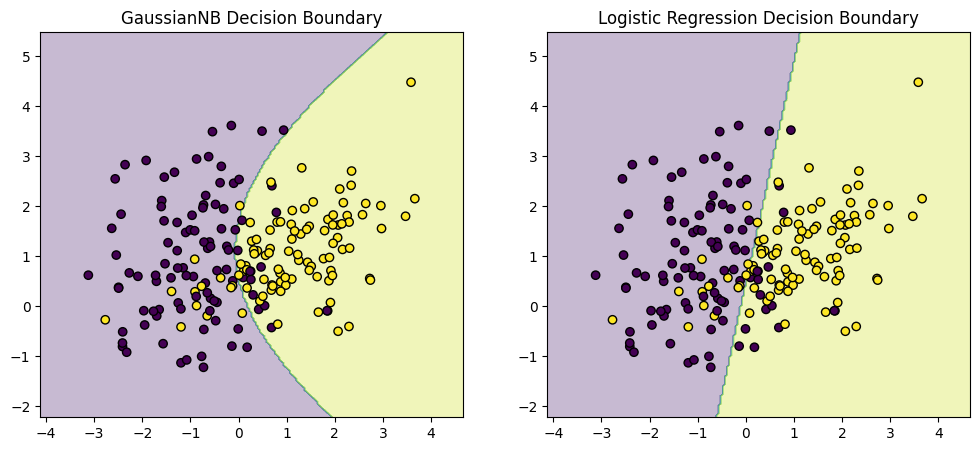

In [11]:
import matplotlib.pyplot as plt
from sklearn.datasets import make_classification
from sklearn.linear_model import LogisticRegression

# Generate synthetic 2D data
X, y = make_classification(n_samples=200, n_features=2, n_redundant=0,
                           n_informative=2, random_state=42, n_clusters_per_class=1)

# Fit models
gnb = GaussianNB().fit(X, y)
lr = LogisticRegression().fit(X, y)

# Plotting
xx, yy = np.meshgrid(np.linspace(X[:,0].min()-1, X[:,0].max()+1, 200),
                     np.linspace(X[:,1].min()-1, X[:,1].max()+1, 200))
Z_gnb = gnb.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
Z_lr = lr.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(12,5))

# GaussianNB
plt.subplot(1,2,1)
plt.contourf(xx, yy, Z_gnb, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
plt.title("GaussianNB Decision Boundary")

# Logistic Regression
plt.subplot(1,2,2)
plt.contourf(xx, yy, Z_lr, alpha=0.3)
plt.scatter(X[:,0], X[:,1], c=y, edgecolor='k')
plt.title("Logistic Regression Decision Boundary")

plt.show()


### Key difference
| Aspect            | GaussianNB                             | Logistic Regression                |
| ----------------- | -------------------------------------- | ---------------------------------- |
| Type              | Generative                             | Discriminative                     |
| Decision boundary | Curve if variances differ              | Always linear                      |
| Assumption        | Features ~ Gaussian per class          | No feature distribution assumption |
| Multi-feature     | Quadratic surface if unequal variances | Hyperplane                         |


## Gaussian Naive Bayes vs Logistic Regression Decision Boundaries

---

### 1️⃣ Gaussian Naive Bayes Decision Boundary

- **GaussianNB is generative**: it models the distribution of each feature for each class.

$$
x_i \sim \mathcal{N}(\mu_y, \sigma_y^2)
$$

- The posterior probability is:

$$
P(y=1 \mid x) \propto P(y=1) \prod_i P(x_i \mid y=1)
$$

- The **decision boundary** is where:

$$
P(y=1 \mid x) = P(y=0 \mid x)
$$

or equivalently:

$$
\log P(y=1 \mid x) - \log P(y=0 \mid x) = 0
$$

- For **one feature**, if each class has **different variance** ($\sigma_1^2 \neq \sigma_0^2$), the log-odds:

$$
\log \frac{P(y=1 \mid x)}{P(y=0 \mid x)} = \text{some quadratic function of } x
$$

- This is because the Gaussian pdf has a squared term:

$$
\exp\Big(- \frac{(x - \mu_y)^2}{2\sigma_y^2} \Big)
$$

✅ **Result:** The decision boundary is **curved (quadratic)** if class variances differ.  

- If class variances are equal ($\sigma_1^2 = \sigma_0^2$), the squared terms cancel → **linear boundary**.

---

### 2️⃣ Logistic Regression Decision Boundary

- **Logistic Regression is discriminative**: it models $P(y \mid x)$ directly as:

$$
P(y=1 \mid x) = \frac{1}{1 + \exp(-(b_0 + b_1 x_1 + b_2 x_2 + ...))}
$$

- The **decision boundary** is where $P(y=1 \mid x) = 0.5$, i.e.:

$$
b_0 + b_1 x_1 + b_2 x_2 + ... = 0
$$

✅ This is always **linear** in feature space (line in 2D, plane in 3D) regardless of feature distribution.


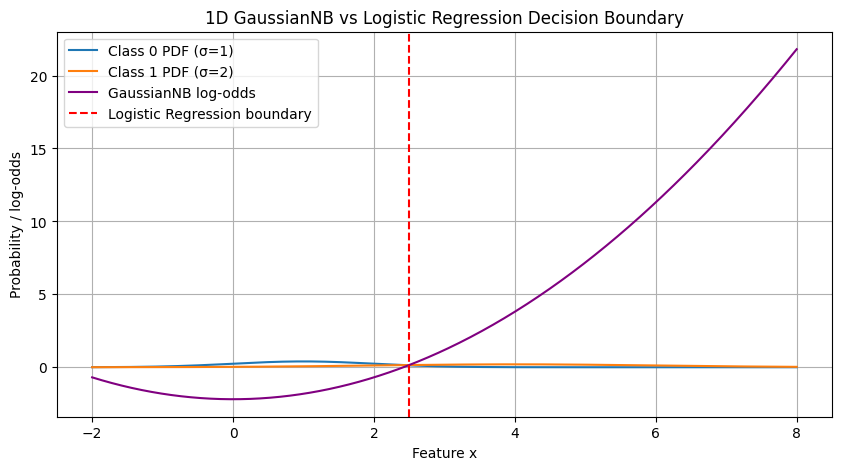

In [13]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression

# Generate 1D feature data
x = np.linspace(-2, 8, 500)

# Gaussian parameters for two classes
mu0, sigma0 = 1, 1
mu1, sigma1 = 4, 2

# Gaussian PDFs
p0 = (1/(np.sqrt(2*np.pi)*sigma0)) * np.exp(-(x - mu0)**2 / (2*sigma0**2))
p1 = (1/(np.sqrt(2*np.pi)*sigma1)) * np.exp(-(x - mu1)**2 / (2*sigma1**2))

# GaussianNB decision boundary (where posteriors are equal)
# Assume equal priors
log_odds = np.log(p1) - np.log(p0)

# Logistic Regression fit (treat the means as "data points")
X_train = np.array([mu0, mu1]).reshape(-1,1)
y_train = np.array([0,1])
lr = LogisticRegression()
lr.fit(X_train, y_train)
logistic_boundary = -(lr.intercept_[0]) / lr.coef_[0][0]

# Plot
plt.figure(figsize=(10,5))
plt.plot(x, p0, label='Class 0 PDF (σ=1)')
plt.plot(x, p1, label='Class 1 PDF (σ=2)')
plt.plot(x, log_odds, label='GaussianNB log-odds', color='purple')
plt.axvline(logistic_boundary, color='red', linestyle='--', label='Logistic Regression boundary')
plt.title('1D GaussianNB vs Logistic Regression Decision Boundary')
plt.xlabel('Feature x')
plt.ylabel('Probability / log-odds')
plt.legend()
plt.grid(True)
plt.show()


## Bias–Variance Discussion: Naive Bayes vs Logistic Regression

---

### 1️⃣ Naive Bayes

**Bias:** High  
**Variance:** Low  

**Why high bias?**

- Strong assumptions:
  - Conditional independence of features.
  - Gaussian (or multinomial/bernoulli) distribution assumptions.
- These assumptions are often unrealistic in real-world data.
- Because the model is heavily constrained, it may **underfit** if assumptions are wrong.

**Why low variance?**

- Very few parameters to estimate.
- Closed-form solution (no iterative optimization).
- Performs well even with small datasets.
- Stable predictions — small changes in data don’t drastically change the model.

**Intuition:**

Naive Bayes makes strong assumptions → simple model → less flexible → high bias but very stable.

---

### 2️⃣ Logistic Regression

**Bias:** Lower  
**Variance:** Higher  

**Why lower bias?**

- No assumption about feature distribution.
- Directly models:

$$
P(y=1 \mid x) = \frac{1}{1 + \exp(-(b_0 + b_1 x_1 + ...))}
$$

- Learns coefficients by maximizing likelihood.
- More flexible than Naive Bayes.

**Why higher variance?**

- Parameters are learned via optimization.
- More sensitive to small training data.
- Can overfit if:
  - Dataset is small
  - Features are high-dimensional
  - Regularization is weak


## Asymptotic Behavior

**Research shows:**
> Generative models (Naive Bayes) converge faster with small datasets.
> Discriminative models (Logistic Regression) achieve lower asymptotic error with large datasets.

*Reference:* Ng, Andrew Y., and Michael I. Jordan. "On discriminative vs. generative classifiers: A comparison of logistic regression and naive Bayes." NIPS 2002.


## Summary & Takeaways
- Naive Bayes is simple, fast, and works well with small datasets.
- GaussianNB → continuous features, MultinomialNB → counts, BernoulliNB → binary features.
- Laplace smoothing avoids zero-frequency problems.
- Log probabilities prevent numerical underflow.
- Logistic Regression is discriminative, flexible, and achieves lower asymptotic error.
- Choose NB variant carefully based on feature type.